# Dataset Summary

## Overview
This dataset combines socio-economic data from the 1990 Census, law enforcement data from the 1990 Law Enforcement Management and Administration Stats (LEMAS) survey, and crime data from the 1995 FBI Uniform Crime Report (UCR). It is designed to explore relationships between socio-economic factors, law enforcement characteristics, and crime rates.

## Characteristics
- **Dataset Characteristics**: Multivariate
- **Feature Type**: Real
- **Subject Area**: Social Science
- **Associated Task**: Regression

## Dataset Details
- **Number of Instances**: 2,215
- **Number of Features**: 147
  - **Predictive Features**: 124
  - **Non-predictive Features**: 4 (for informational purposes)
  - **Potential Goal Variables**: 18



**Source**: https://archive.ics.uci.edu/dataset/211/communities+and+crime+unnormalized


In [1]:
import pandas as pd

# Specify the path to your CSV file
file_path = 'crime.csv'

# Load the CSV file into a DataFrame
df = pd.read_csv(file_path)

df.head()


,communityname,State,countyCode,communityCode,fold,pop,perHoush,pctBlack,pctWhite,pctAsian,...,burglaries,burglPerPop,larcenies,larcPerPop,autoTheft,autoTheftPerPop,arsons,arsonsPerPop,violentPerPop,nonViolPerPop
0,BerkeleyHeightstownship,NJ,39,5320,1,11980,3.10,1.37,91.78,6.50,...,14.1,114.85,138,1132.08,16,131.26,2,16.41,41.02,1394.59
1,Marpletownship,PA,45,47616,1,23123,2.82,0.80,95.57,3.44,...,57,242.37,376,1598.78,26,110.55,1,4.25,127.56,1955.95
2,Tigardcity,OR,?,?,1,29344,2.43,0.74,94.33,3.43,...,274,758.14,1797,4972.19,136,376.3,22,60.87,218.59,6167.51
3,Gloversvillecity,NY,35,29443,1,16656,2.40,1.70,97.35,0.50,...,225,1301.78,716,4142.56,47,271.93,?,?,306.64,?
4,Bemidjicity,MN,7,5068,1,11245,2.76,0.53,89.16,1.17,...,91,728.93,1060,8490.87,91,728.93,5,40.05,?,9988.79


In [2]:
df.describe()

,fold,pop,perHoush,pctBlack,pctWhite,pctAsian,pctHisp,pct12-21,pct12-29,pct16-24,...,pctForeignBorn,pctBornStateResid,pctSameHouse-5,pctSameCounty-5,pctSameState-5,popDensity,pctUsePubTrans,pctOfficDrugUnit,murders,murdPerPop
count,2215.000000,2.215000e+03,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,...,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000
mean,5.494357,5.311798e+04,2.707327,9.335102,83.979819,2.670203,7.950176,14.445837,27.644840,13.975142,...,7.340302,61.539630,51.538596,77.411079,88.111865,2783.835034,3.041124,0.980253,7.764921,5.859476
std,2.872924,2.046203e+05,0.334120,14.247156,16.419080,4.473843,14.589832,4.518623,6.181517,5.970747,...,8.418476,16.750061,10.517926,10.878186,7.287836,2828.993341,4.912917,2.877100,58.166451,9.156717
min,1.000000,1.000500e+04,1.600000,0.000000,2.680000,0.030000,0.120000,4.580000,9.380000,4.640000,...,0.180000,6.750000,11.830000,27.950000,32.830000,10.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,1.436600e+04,2.500000,0.860000,76.320000,0.620000,0.930000,12.250000,24.415000,11.320000,...,2.060000,50.110000,44.995000,72.060000,85.200000,1181.900000,0.360000,0.000000,0.000000,0.000000
50%,5.000000,2.279200e+04,2.660000,2.870000,90.350000,1.230000,2.180000,13.620000,26.780000,12.540000,...,4.310000,64.490000,52.170000,79.490000,90.030000,2027.300000,1.220000,0.000000,1.000000,2.170000
75%,8.000000,4.302400e+04,2.850000,11.145000,96.225000,2.670000,7.810000,15.360000,29.205000,14.345000,...,9.250000,74.855000,58.740000,85.135000,93.010000,3321.700000,3.365000,0.000000,3.000000,8.365000
max,10.000000,7.322564e+06,5.280000,96.670000,99.630000,57.460000,95.290000,54.400000,70.510000,63.620000,...,60.400000,93.140000,78.560000,96.590000,99.900000,44229.900000,54.330000,48.440000,1946.000000,91.090000


## First ,we check with missing data

In [3]:
import numpy as np

# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)


In [4]:
# Summary table of columns with missing data
missing_summary = df.isnull().sum()[df.isnull().sum() > 0].to_frame('Missing Count')
missing_summary['Missing Percentage'] = (df.isnull().mean() * 100)[df.isnull().sum() > 0]
print(missing_summary)


                   Missing Count  Missing Percentage
countyCode                  1221           55.124153
communityCode               1224           55.259594
otherPerCap                    1            0.045147
numPolice                   1872           84.514673
policePerPop                1871           84.469526
policeField                 1871           84.469526
policeFieldPerPop           1871           84.469526
policeCalls                 1871           84.469526
policCallPerPop             1871           84.469526
policCallPerOffic           1871           84.469526
policePerPop2               1871           84.469526
racialMatch                 1871           84.469526
pctPolicWhite               1871           84.469526
pctPolicBlack               1871           84.469526
pctPolicHisp                1871           84.469526
pctPolicAsian               1871           84.469526
pctPolicMinority            1871           84.469526
officDrugUnits              1871           84.

## Dataset including 3 part,4 non-rediction columns, and 125 predictive and  18 target goal(type of crime)

In [5]:
# Define the list of ID columns
id_columns = ['communityname', 'State', 'countyCode', 'communityCode', 'fold']

# Separate ID columns from the DataFrame
df_id = df[id_columns]

# Remove ID columns to leave only features and targets
df_features_targets = df.drop(columns=id_columns)

# If needed, separate features and targets further
# Assuming targets start from column index 124
feature_columns = df_features_targets.columns[:124]  # Adjust if necessary
target_columns = df_features_targets.columns[124:]

# Separate features and targets
df_features = df_features_targets[feature_columns]
df_targets = df_features_targets[target_columns]


In [6]:
# Display the target columns
print(target_columns)


Index(['murders', 'murdPerPop', 'rapes', 'rapesPerPop', 'robberies',
       'robbbPerPop', 'assaults', 'assaultPerPop', 'burglaries', 'burglPerPop',
       'larcenies', 'larcPerPop', 'autoTheft', 'autoTheftPerPop', 'arsons',
       'arsonsPerPop', 'violentPerPop', 'nonViolPerPop'],
      dtype='object')


## Separate features and target variables, for feature varaibles, we first drop missing data that more than 80% percentange 

In [7]:
# Select the first 124 columns as feature columns
feature_columns = df_features_targets.columns[:124]
df_features = df_features_targets[feature_columns]

# Calculate the percentage of missing data in these feature columns
missing_percentage = df_features.isnull().mean() * 100

# Identify columns with more than 80% missing data
columns_to_drop = missing_percentage[missing_percentage > 80].index
print("Columns to drop due to high missing data:", columns_to_drop)

# Drop these columns from the feature DataFrame
df_features_cleaned = df_features.drop(columns=columns_to_drop)

# Display the remaining feature columns after dropping
print("Remaining feature columns:", df_features_cleaned.columns)


Columns to drop due to high missing data: Index(['numPolice', 'policePerPop', 'policeField', 'policeFieldPerPop',
       'policeCalls', 'policCallPerPop', 'policCallPerOffic', 'policePerPop2',
       'racialMatch', 'pctPolicWhite', 'pctPolicBlack', 'pctPolicHisp',
       'pctPolicAsian', 'pctPolicMinority', 'officDrugUnits',
       'numDiffDrugsSeiz', 'policAveOT', 'policCarsAvail', 'policOperBudget',
       'pctPolicPatrol', 'gangUnit', 'policBudgetPerPop'],
      dtype='object')
Remaining feature columns: Index(['pop', 'perHoush', 'pctBlack', 'pctWhite', 'pctAsian', 'pctHisp',
       'pct12-21', 'pct12-29', 'pct16-24', 'pct65up',
       ...
       'persHomeless', 'pctForeignBorn', 'pctBornStateResid', 'pctSameHouse-5',
       'pctSameCounty-5', 'pctSameState-5', 'landArea', 'popDensity',
       'pctUsePubTrans', 'pctOfficDrugUnit'],
      dtype='object', length=102)


## Since this is a regression problem ,we first check variables that is non numeric

In [8]:
# Identify non-numeric columns in df_features_cleaned
non_numeric_features = df_features_cleaned.select_dtypes(exclude=['float', 'int']).columns

# Display the non-numeric columns and their data types
print("Non-numeric features and their data types:")
print(df_features_cleaned[non_numeric_features].dtypes)



Non-numeric features and their data types:
otherPerCap       object
pctNotSpeakEng    object
landArea          object
dtype: object


##  convert non-numeric data to numeric , for some error we replace with NaN

In [9]:
# Check the unique values in each column to understand the data
for column in non_numeric_features:
    print(f"Unique values in {column}:")
    print(df_features_cleaned[column].unique())
    print("\n")

# Attempt to convert to numeric, replacing non-convertible values with NaN to identify issues
for column in non_numeric_features:
    df_features_cleaned[column] = df_features_cleaned[column].astype(str)
    df_features_cleaned[column] = pd.to_numeric(df_features_cleaned[column], errors='coerce')

# Display the columns again to confirm if conversion was successful
print("Data types after conversion attempt:")
print(df_features_cleaned[non_numeric_features].dtypes)


Unique values in otherPerCap:
['5115' '5250' '5954' ... '8532' '4436' '7540']


Unique values in pctNotSpeakEng:
['1.37.1' '1.81' '1.14' '0.56' '0.39' '0.6' '0.28' '0.43' '2.51' '0.81'
 '10.8' '0.59' '0.54' '0.42' '0.69' '0.92' '15.46' '0.53' '2.2' '9.84'
 '4.31' '1.23' '0.75' '1.21' '3.17' '2.94' '0.18' '2.4' '21.64' '2.49'
 '0.24' '0.61' '3.08' '0.68' '2.25' '0.21' '1.64' '3.89' '0.45' '1.35'
 '0.31' '0.51' '0.85' '2.03' '14.64' '0.95' '4.86' '0.8' '2.63' '1.63'
 '0.7' '0.35' '0.44' '1.19' '0.67' '0.47' '0.49' '0.52' '0.48' '0.71'
 '1.53' '0.55' '1.15' '0.23' '0.29' '4.14' '1.0' '1.76' '1.02' '0.93'
 '0.13' '1.06' '3.21' '2.17' '2.59' '5.83' '0.84' '7.86' '0.76' '0.26'
 '0.3' '3.93' '1.1' '0.83' '1.26' '0.57' '3.07' '8.21' '1.99' '1.58'
 '1.48' '3.36' '0.15' '2.43' '0.25' '1.24' '5.43' '3.33' '0.73' '1.78'
 '0.19' '17.45' '16.23' '1.46' '0.17' '5.54' '1.01' '1.57' '1.28' '2.19'
 '1.31' '0.74' '1.41' '2.64' '30.91' '3.38' '0.64' '7.03' '1.04' '14.8'
 '2.02' '1.77' '0.32' '0.38' '0.08'

In [10]:
# Calculate the percentage of missing data in non-numeric feature columns
missing_percentage_non_numeric = df_features[non_numeric_features].isnull().mean() * 100

# Display the results
print("Percentage of missing data in non-numeric feature columns:")
print(missing_percentage_non_numeric)


Percentage of missing data in non-numeric feature columns:
otherPerCap       0.045147
pctNotSpeakEng    0.000000
landArea          0.000000
dtype: float64


In [11]:
# Display the data types of non-numeric columns
print("Data types of non-numeric target columns:")
print(df_targets.dtypes)


Data types of non-numeric target columns:
murders            float64
murdPerPop         float64
rapes               object
rapesPerPop         object
robberies           object
robbbPerPop         object
assaults            object
assaultPerPop       object
burglaries          object
burglPerPop         object
larcenies           object
larcPerPop          object
autoTheft           object
autoTheftPerPop     object
arsons              object
arsonsPerPop        object
violentPerPop       object
nonViolPerPop       object
dtype: object


In [12]:
# Identify non-numeric columns in df_features
non_numeric_targets = df_features_cleaned.select_dtypes(exclude=['float', 'int']).columns
print("Non-numeric feature columns:", non_numeric_targets)


Non-numeric feature columns: Index([], dtype='object')


In [13]:
# Identify non-numeric columns in df_targets
non_numeric_targets = df_targets.select_dtypes(exclude=['float', 'int']).columns
print("Non-numeric target columns:", non_numeric_targets)


Non-numeric target columns: Index(['rapes', 'rapesPerPop', 'robberies', 'robbbPerPop', 'assaults',
       'assaultPerPop', 'burglaries', 'burglPerPop', 'larcenies', 'larcPerPop',
       'autoTheft', 'autoTheftPerPop', 'arsons', 'arsonsPerPop',
       'violentPerPop', 'nonViolPerPop'],
      dtype='object')


In [14]:
df_targets.head()

,murders,murdPerPop,rapes,rapesPerPop,robberies,robbbPerPop,assaults,assaultPerPop,burglaries,burglPerPop,larcenies,larcPerPop,autoTheft,autoTheftPerPop,arsons,arsonsPerPop,violentPerPop,nonViolPerPop
0,0.3,0.4,0.5,0.6,1.1,8.2,4,32.81,14.1,114.85,138,1132.08,16,131.26,2,16.41,41.02,1394.59
1,0.0,0.0,1,4.25,5,21.26,24,102.05,57,242.37,376,1598.78,26,110.55,1,4.25,127.56,1955.95
2,3.0,8.3,6,16.6,56,154.95,14,38.74,274,758.14,1797,4972.19,136,376.3,22,60.87,218.59,6167.51
3,0.0,0.0,10,57.86,10,57.86,33,190.93,225,1301.78,716,4142.56,47,271.93,NaN,NaN,306.64,NaN
4,0.0,0.0,NaN,NaN,4,32.04,14,112.14,91,728.93,1060,8490.87,91,728.93,5,40.05,NaN,9988.79


# impute missing df_id

In [15]:
# Calculate the percentage of missing values for each column in df_id
missing_percentage = df_id.isnull().mean() * 100

# Display the missing percentage for each ID column
print("Percentage of missing values in each ID column:\n", missing_percentage)


Percentage of missing values in each ID column:
 communityname     0.000000
State             0.000000
countyCode       55.124153
communityCode    55.259594
fold              0.000000
dtype: float64


In [16]:
from sklearn.preprocessing import LabelEncoder

# Apply label encoding to categorical columns in df_id
for col in df_id.columns:
    if df_id[col].dtype == 'object':
        le = LabelEncoder()
        df_id.loc[:, col] = le.fit_transform(df_id[col].astype(str))



In [17]:
from sklearn.impute import KNNImputer
import pandas as pd

# Initialize the KNN imputer with the number of neighbors
knn_imputer = KNNImputer(n_neighbors=3)

# Perform KNN imputation
df_id_imputed = pd.DataFrame(knn_imputer.fit_transform(df_id), columns=df_id.columns)

# Verify that the missing values have been imputed
print("Missing values after KNN imputation:\n", df_id_imputed.isnull().sum())



Missing values after KNN imputation:
 communityname    0
State            0
countyCode       0
communityCode    0
fold             0
dtype: int64


# Impute df_features_cleaned and df_targets using SimpleImputer

In [18]:
from sklearn.impute import SimpleImputer


# Separate numerical and categorical columns in df_features_cleaned
num_features = df_features_cleaned.select_dtypes(include=['float', 'int']).columns


# Mean imputation for numerical features
num_imputer = SimpleImputer(strategy='median')
df_features_cleaned[num_features] = num_imputer.fit_transform(df_features_cleaned[num_features])


# Check if there are any remaining missing values
print("Remaining missing values in df_features_cleaned:\n", df_features_cleaned.isnull().sum())


Remaining missing values in df_features_cleaned:
 pop                 0
perHoush            0
pctBlack            0
pctWhite            0
pctAsian            0
                   ..
pctSameState-5      0
landArea            0
popDensity          0
pctUsePubTrans      0
pctOfficDrugUnit    0
Length: 102, dtype: int64


In [19]:
# Impute missing values in the target variables using mean strategy
target_imputer = SimpleImputer(strategy='median')
df_targets= pd.DataFrame(target_imputer.fit_transform(df_targets), columns=df_targets.columns)

# Check if there are any remaining missing values
print("Remaining missing values in df_targets:\n", df_targets.isnull().sum())


Remaining missing values in df_targets:
 murders            0
murdPerPop         0
rapes              0
rapesPerPop        0
robberies          0
robbbPerPop        0
assaults           0
assaultPerPop      0
burglaries         0
burglPerPop        0
larcenies          0
larcPerPop         0
autoTheft          0
autoTheftPerPop    0
arsons             0
arsonsPerPop       0
violentPerPop      0
nonViolPerPop      0
dtype: int64


# output the cleaned dataset

In [20]:

# Combine the DataFrames along columns
df_combined = pd.concat([df_id_imputed, df_features_cleaned, df_targets], axis=1)

# Output the combined DataFrame to a CSV file
df_combined.to_csv("cleaned_output.csv", index=False)

print("Data successfully saved to combined_output.csv")


Data successfully saved to combined_output.csv


In [21]:
non_numeric_columns = df_combined.select_dtypes(include=['object', 'category']).columns
print("Non-numeric columns:", non_numeric_columns)


Non-numeric columns: Index([], dtype='object')


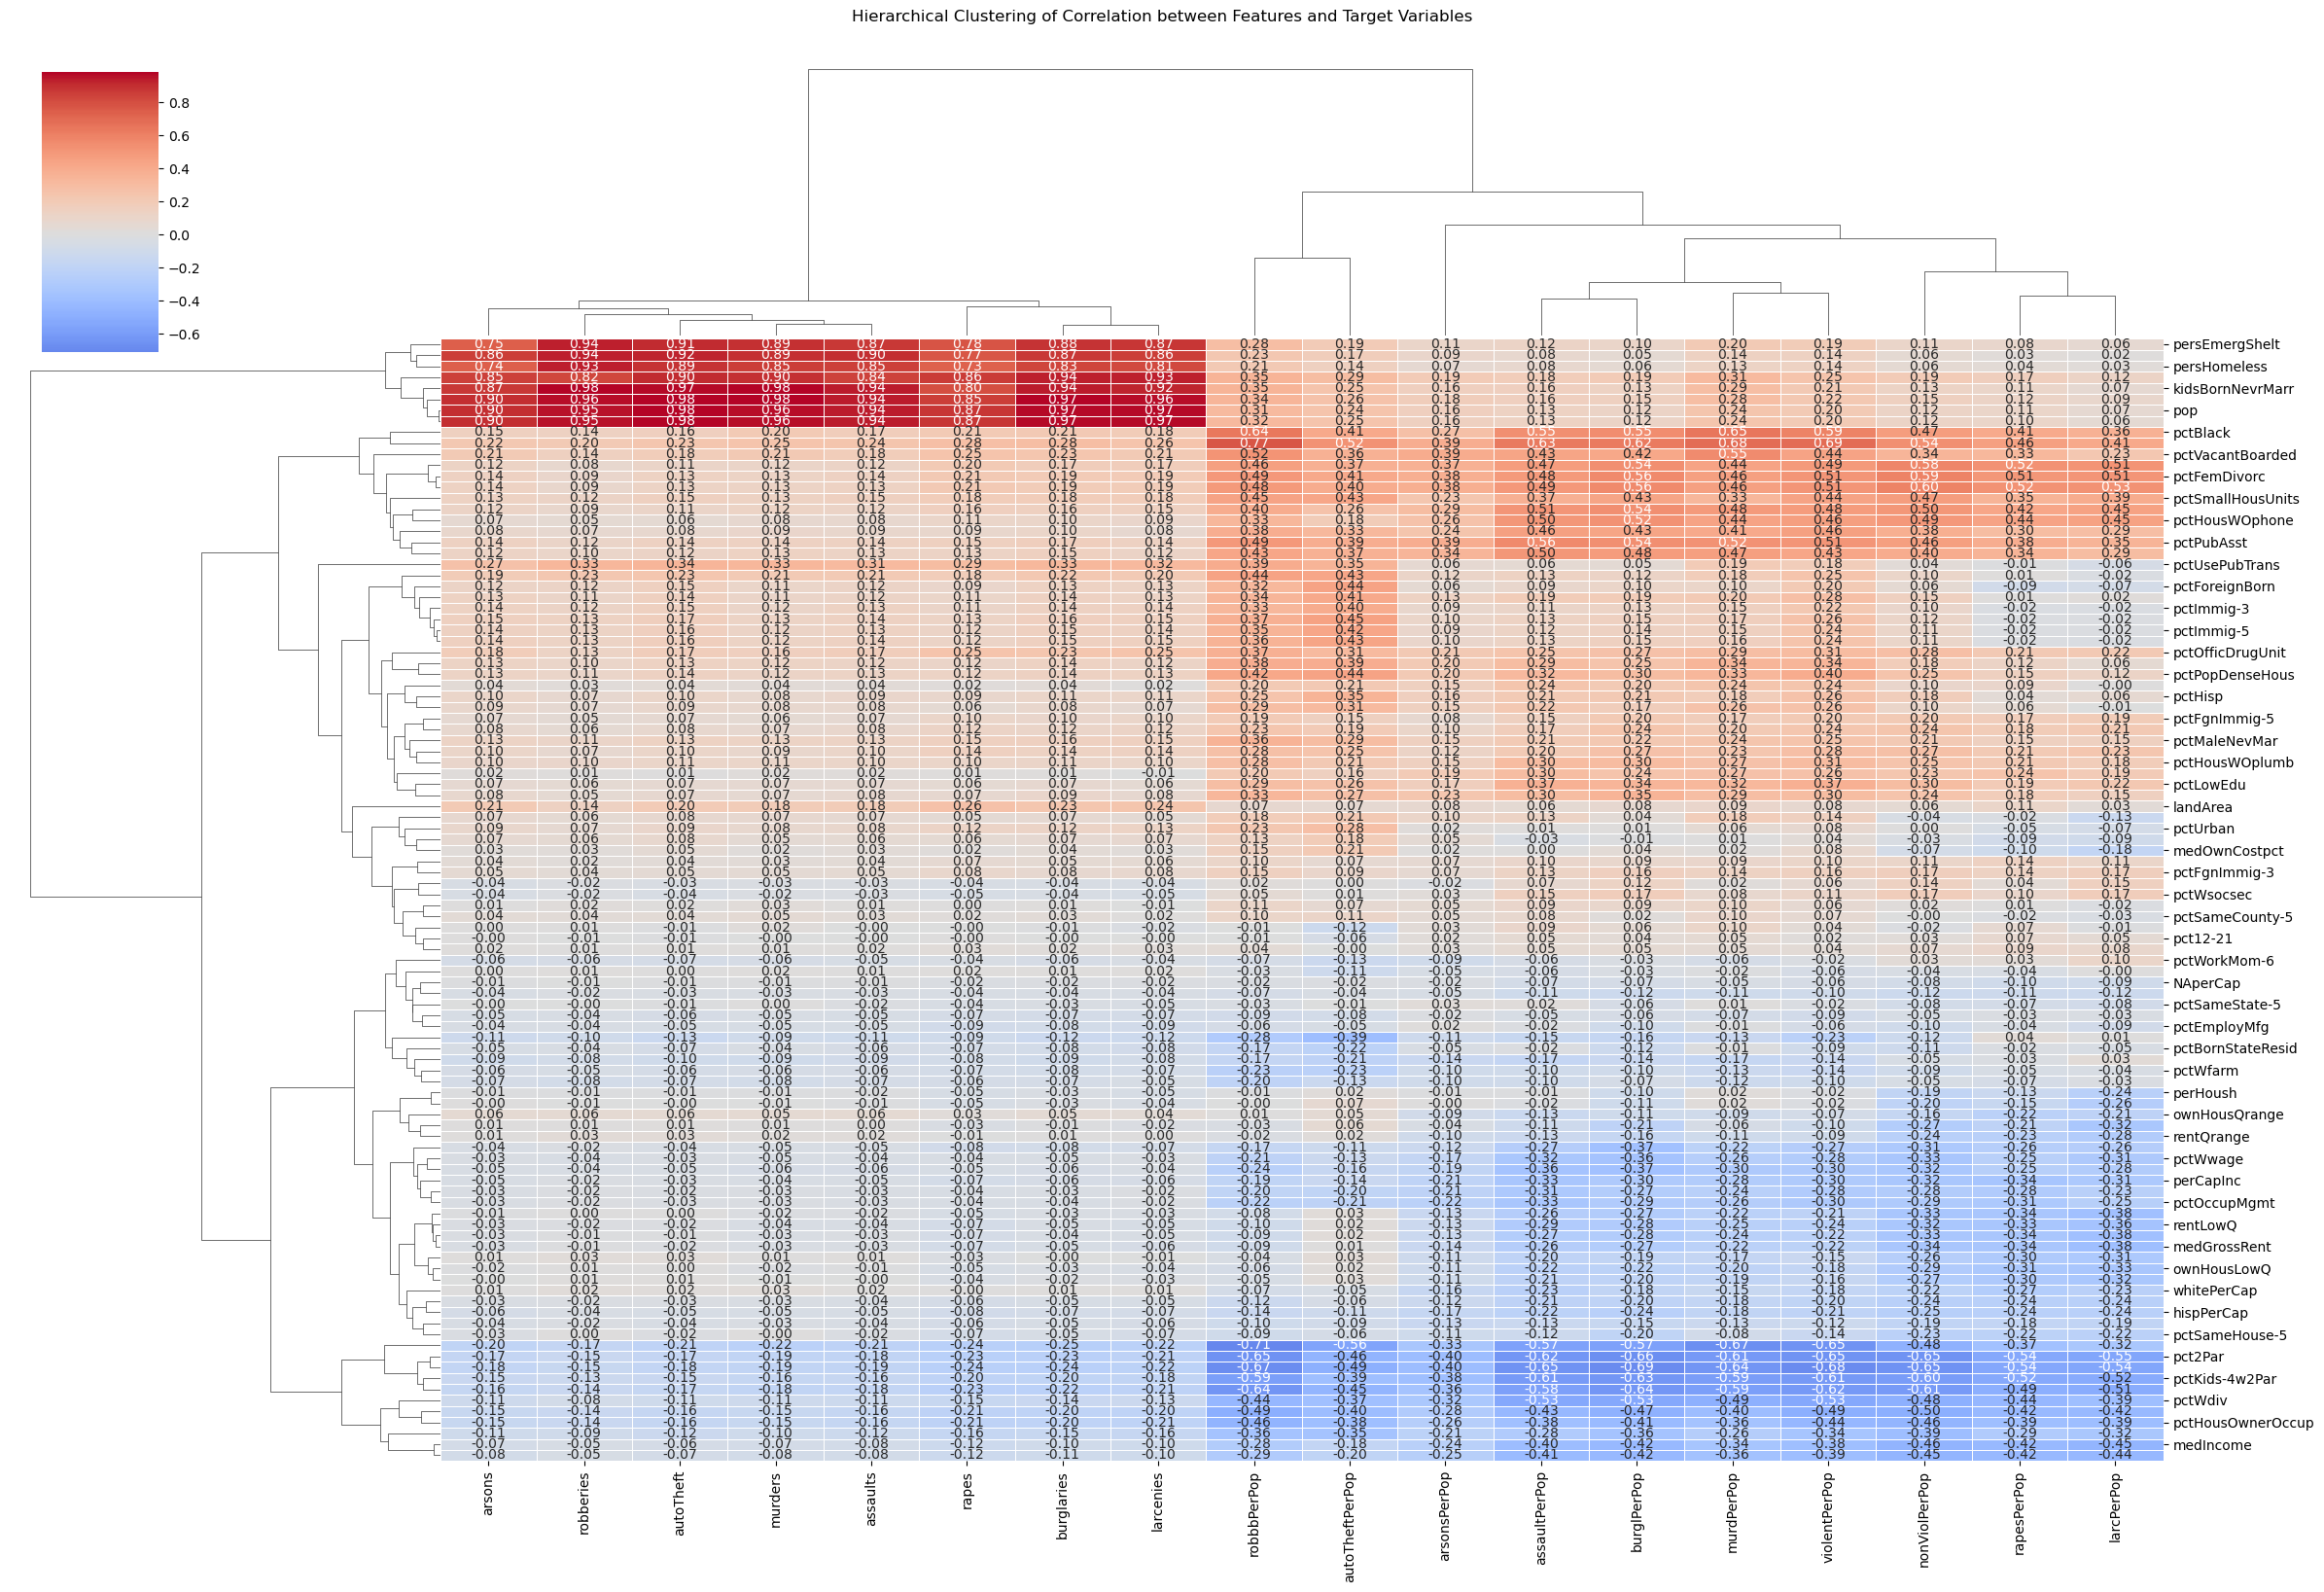

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Combine features and targets into one DataFrame to calculate correlations
df_combined = pd.concat([df_features_cleaned, df_targets], axis=1)

# Calculate the correlation matrix for the combined DataFrame
correlation_matrix = df_combined.corr()

# Extract only the correlations between features and target variables
correlation_with_targets = correlation_matrix.loc[df_features_cleaned.columns, df_targets.columns]

# Plot the hierarchical clustering heatmap
clustermap = sns.clustermap(
    correlation_with_targets,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5,
    figsize=(24, 16)
)

# Add a title for the entire figure
plt.suptitle("Hierarchical Clustering of Correlation between Features and Target Variables", y=1.02)

# Save the clustermap to a file
clustermap.savefig("hierarchical_clustering_correlation.png")

# Display the clustermap
plt.show()

## train test split

### Train and test split by fold

# build the model with random forest

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

# Example: df_cleaned is your cleaned DataFrame containing features and target columns
# Ensure that target_columns contains your target variable names
target_columns = [
    'arsons', 'robberies', 'autoTheft', 'murders', 'assaults', 'rapes', 'burglaries', 'larcenies',
    'robbbPerPop', 'autoTheftPerPop', 'arsonsPerPop', 'assaultPerPop', 'burglPerPop', 
    'murdPerPop', 'violentPerPop', 'nonViolPerPop', 'rapesPerPop', 'larcPerPop'
]  # Modify as per your dataset

# Assume df_features_cleaned and df_targets are your DataFrame for features and targets respectively
X = df_features_cleaned  # Features
y = df_targets           # Targets

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the RandomForest model
model = RandomForestRegressor(n_estimators=100, random_state=42)

# For each target column, train a model and evaluate
for target in target_columns:
    print(f"Training model for {target}...")

    # Train the model for each target column
    model.fit(X_train, y_train[target])

    # Make predictions on the training data and test data
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate RMSE for both training and testing sets
    train_rmse = np.sqrt(mean_squared_error(y_train[target], y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test[target], y_test_pred))

    print(f"Training RMSE for {target}: {train_rmse}")
    print(f"Testing RMSE for {target}: {test_rmse}\n")

    # Feature Importance (Optional, for understanding model)
    feature_importance = model.feature_importances_
    feature_importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': feature_importance
    }).sort_values(by='Importance', ascending=False)

    print(f"Feature Importance for {target}:\n{feature_importance_df.head()}\n")




Training model for arsons...
Training RMSE for arsons: 35.24378888093579
Testing RMSE for arsons: 55.281111363549535

Feature Importance for arsons:
           Feature  Importance
27     persPoverty    0.259331
10       persUrban    0.160909
71     houseVacant    0.108065
51  numForeignBorn    0.106933
0              pop    0.099527

Training model for robberies...
Training RMSE for robberies: 613.145889343331
Testing RMSE for robberies: 160.49820381008664

Feature Importance for robberies:
             Feature  Importance
49  kidsBornNevrMarr    0.247420
51    numForeignBorn    0.144899
92      persHomeless    0.099193
10         persUrban    0.098976
91    persEmergShelt    0.089470

Training model for autoTheft...
Training RMSE for autoTheft: 863.8699353409656
Testing RMSE for autoTheft: 468.8216157877075

Feature Importance for autoTheft:
             Feature  Importance
27       persPoverty    0.289577
10         persUrban    0.157049
49  kidsBornNevrMarr    0.115401
0            

## using RandomizedSearchCV to search hyperparameters

In [57]:

from sklearn.model_selection import RandomizedSearchCV
# Define the hyperparameter grid
param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]  # Use valid options only
}


# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# For each target column, tune hyperparameters and evaluate the model
for target in target_columns:
    print(f"Tuning and training model for {target}...")

    # Initialize the model
    model = RandomForestRegressor(random_state=42)

    # Perform RandomizedSearchCV
    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        n_iter=50,  # Number of parameter settings to sample
        scoring='neg_mean_squared_error',  # Use negative MSE as the scoring metric
        cv=3,  # 3-fold cross-validation
        verbose=1,
        random_state=42,
        n_jobs=-1  # Use all available cores
    )

    # Train using RandomizedSearchCV
    random_search.fit(X_train, y_train[target])

    # Best model from RandomizedSearchCV
    best_model = random_search.best_estimator_

    # Make predictions on the test set
    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)

    # Calculate RMSE for both training and testing sets
    train_rmse = np.sqrt(mean_squared_error(y_train[target], y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test[target], y_test_pred))

    print(f"Training RMSE for {target}: {train_rmse}")
    print(f"Testing RMSE for {target}: {test_rmse}")
    print(f"Best Parameters for {target}: {random_search.best_params_}\n")

    # Feature Importance (Optional)
    feature_importance = best_model.feature_importances_
    feature_importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': feature_importance
    }).sort_values(by='Importance', ascending=False)

    print(f"Feature Importance for {target}:\n{feature_importance_df.head()}\n")


Tuning and training model for arsons...
Fitting 3 folds for each of 50 candidates, totalling 150 fits
Training RMSE for arsons: 36.2003466936479
Testing RMSE for arsons: 55.93325838828937
Best Parameters for arsons: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 10}

Feature Importance for arsons:
           Feature  Importance
27     persPoverty    0.258770
10       persUrban    0.160166
71     houseVacant    0.109640
51  numForeignBorn    0.104409
0              pop    0.097741

Tuning and training model for robberies...
Fitting 3 folds for each of 50 candidates, totalling 150 fits
Training RMSE for robberies: 861.6717451258203
Testing RMSE for robberies: 154.1417335824502
Best Parameters for robberies: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 30}

Feature Importance for robberies:
             Feature  Importance
49  kidsBornNevrMarr    0.264576
51    numForeignBo

## Now we are  going to using a differnt model Linearregressor

## Use lasso to select  features

In [23]:
from sklearn.linear_model import MultiTaskLasso, LinearRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


# Example dataset setup (df_features_cleaned: features, df_targets: targets)
X = df_features_cleaned  # Features
y = df_targets           # Targets (multi-output)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Lasso for Feature Selection Across All Targets
# MultiTaskLasso applies Lasso regularization across multiple targets jointly
lasso = MultiTaskLasso(alpha=10, random_state=42)  # Adjust alpha as needed
lasso.fit(X_train, y_train)

# Identify selected features
selected_features = X.columns[(lasso.coef_ != 0).any(axis=0)]  # Features with non-zero coefficients

# Count the number of selected features
num_selected_features = len(selected_features)

# Print the selected features and their count
print(f"Selected Features ({num_selected_features} out of {X.shape[1]}): {selected_features}")




Selected Features (95 out of 102): Index(['pop', 'pctBlack', 'pctWhite', 'pctAsian', 'pctHisp', 'pct12-21',
       'pct12-29', 'pct16-24', 'pct65up', 'persUrban', 'pctUrban', 'medIncome',
       'pctWwage', 'pctWfarm', 'pctWdiv', 'pctWsocsec', 'pctPubAsst',
       'pctRetire', 'medFamIncome', 'perCapInc', 'whitePerCap', 'blackPerCap',
       'NAperCap', 'asianPerCap', 'otherPerCap', 'hispPerCap', 'persPoverty',
       'pctPoverty', 'pctLowEdu', 'pctNotHSgrad', 'pctCollGrad', 'pctUnemploy',
       'pctEmploy', 'pctEmployMfg', 'pctEmployProfServ', 'pctOccupManu',
       'pctOccupMgmt', 'pctMaleDivorc', 'pctMaleNevMar', 'pctFemDivorc',
       'pct2Par', 'pctKids2Par', 'pctKids-4w2Par', 'pct12-17w2Par',
       'pctWorkMom-6', 'pctWorkMom-18', 'kidsBornNevrMarr',
       'pctKidsBornNevrMarr', 'numForeignBorn', 'pctFgnImmig-3',
       'pctFgnImmig-5', 'pctFgnImmig-8', 'pctFgnImmig-10', 'pctImmig-3',
       'pctImmig-8', 'pctImmig-10', 'pctSpeakOnlyEng', 'pctNotSpeakEng',
       'pctLargHousF

C:\Users\hyz20\miniconda3\envs\gpu-env\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:2559: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 7108701848.604094, tolerance: 20394365.601651397
  ) = cd_fast.enet_coordinate_descent_multi_task(


In [26]:
# Reduce dataset to selected features
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

# 2. MultiOutputRegressor with Linear Regression
# Train the multi-output regressor using the reduced feature set
multi_model = MultiOutputRegressor(LinearRegression())
multi_model.fit(X_train_selected, y_train)

# Predict targets for the training set
y_train_pred = multi_model.predict(X_train_selected)

# Predict targets for the test set
y_test_pred = multi_model.predict(X_test_selected)

# 3. Evaluate the Model

# Calculate Training Error
mse_train_per_target = mean_squared_error(y_train, y_train_pred, multioutput='raw_values')
r2_train_per_target = r2_score(y_train, y_train_pred, multioutput='raw_values')

# Calculate Testing Error
mse_test_per_target = mean_squared_error(y_test, y_test_pred, multioutput='raw_values')
r2_test_per_target = r2_score(y_test, y_test_pred, multioutput='raw_values')

# Combine results for each target
results = pd.DataFrame({
    'Target': y.columns,
    'Train MSE': mse_train_per_target,
    'Train R2': r2_train_per_target,
    'Test MSE': mse_test_per_target,
    'Test R2': r2_test_per_target
})

# Display results for each target
print(results)

# Overall evaluation
overall_train_mse = mean_squared_error(y_train, y_train_pred)
overall_train_r2 = r2_score(y_train, y_train_pred)

overall_test_mse = mean_squared_error(y_test, y_test_pred)
overall_test_r2 = r2_score(y_test, y_test_pred)

print(f"Overall Training Mean Squared Error: {overall_train_mse}")
print(f"Overall Training R-squared: {overall_train_r2}")
print(f"Overall Testing Mean Squared Error: {overall_test_mse}")
print(f"Overall Testing R-squared: {overall_test_r2}")


             Target     Train MSE  Train R2      Test MSE   Test R2
0           murders  9.346124e+01  0.977538  4.930313e+01  0.805529
1        murdPerPop  3.320531e+01  0.611798  2.821527e+01  0.632732
2             rapes  1.776768e+03  0.847807  1.012185e+03  0.745944
3       rapesPerPop  6.044827e+02  0.423983  7.513256e+02  0.345497
4         robberies  9.815630e+04  0.984367  3.977949e+04  0.775458
5       robbbPerPop  1.276362e+04  0.771341  1.182935e+04  0.769819
6          assaults  3.457895e+05  0.928052  1.748280e+05  0.563368
7     assaultPerPop  9.615198e+04  0.521703  8.349871e+04  0.444442
8        burglaries  3.328298e+05  0.970853  2.534967e+05  0.903491
9       burglPerPop  2.365788e+05  0.602350  2.489568e+05  0.528962
10        larcenies  2.213800e+06  0.967643  1.008442e+06  0.930467
11       larcPerPop  1.442425e+06  0.536042  3.905277e+06  0.301592
12        autoTheft  2.227138e+05  0.982673  2.940986e+05  0.809284
13  autoTheftPerPop  9.705196e+04  0.613934  1.2

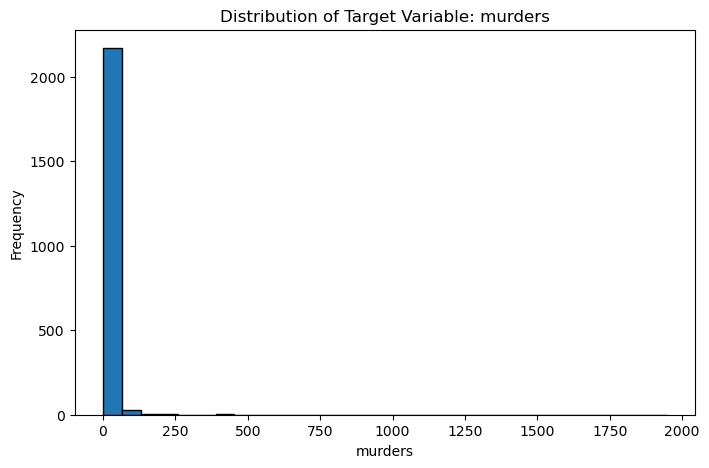

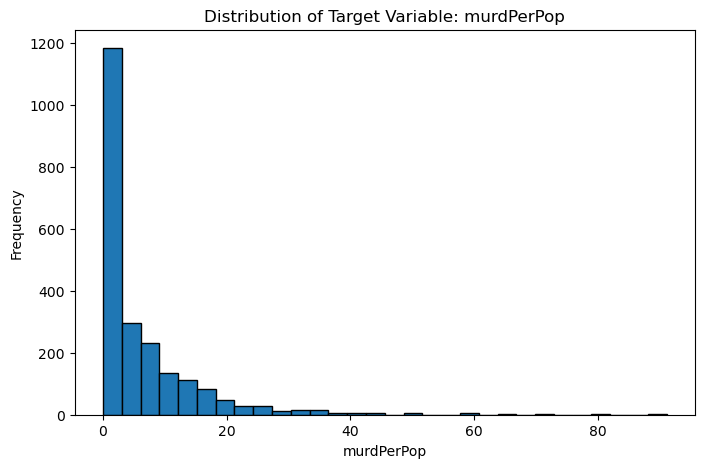

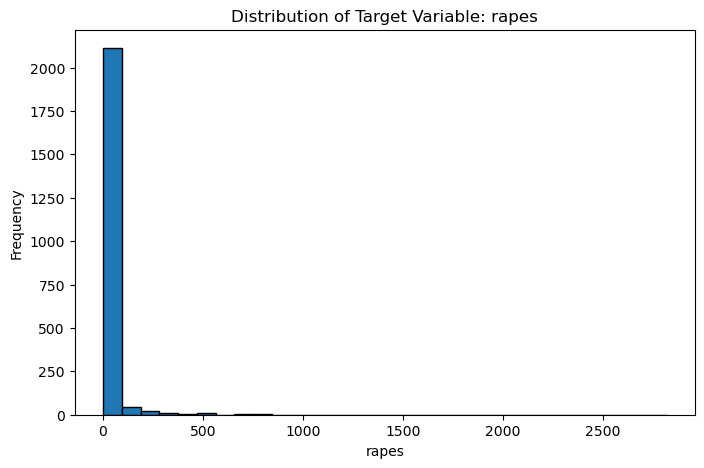

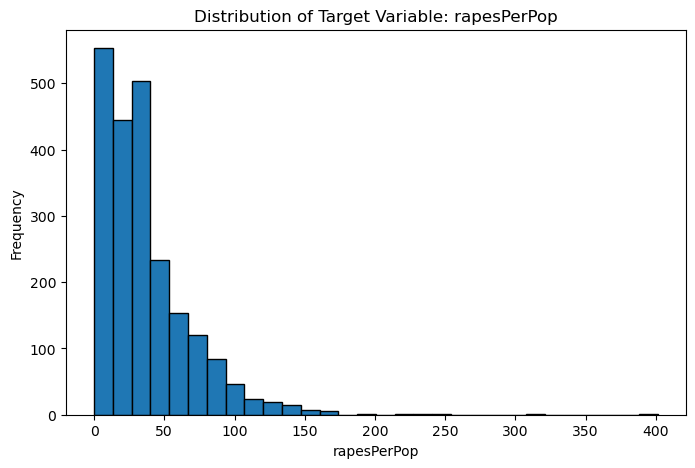

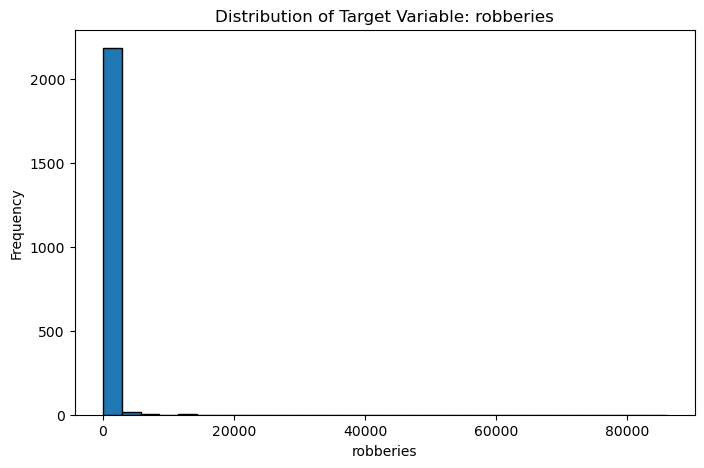

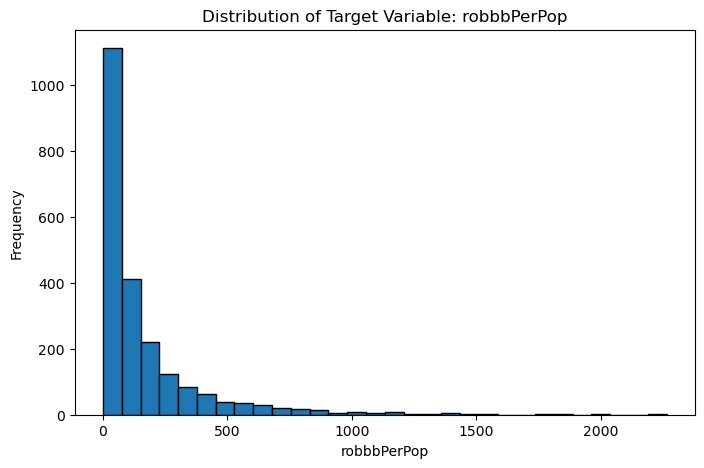

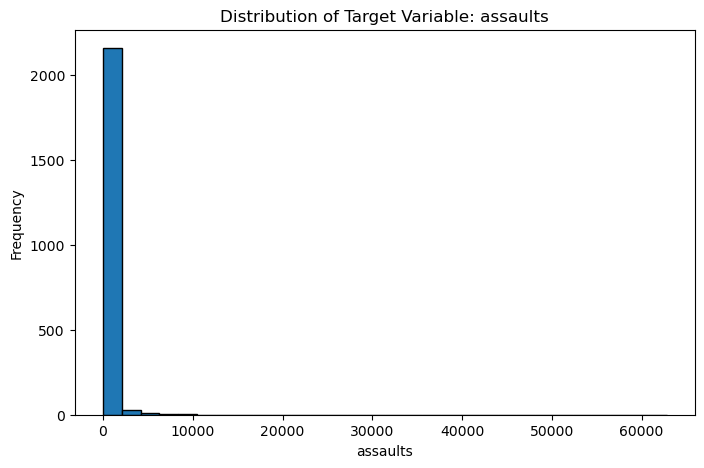

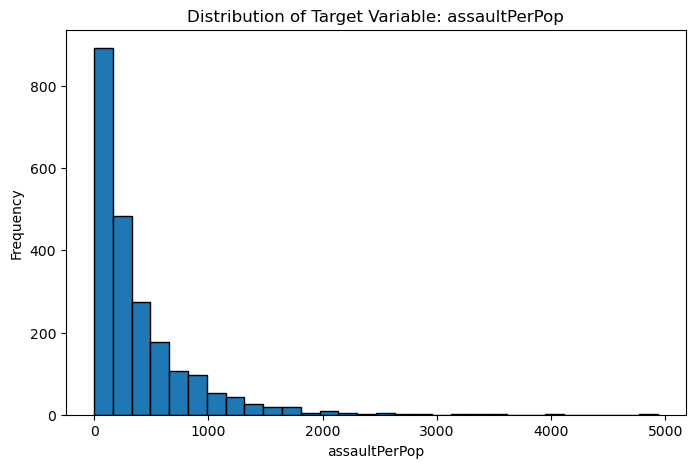

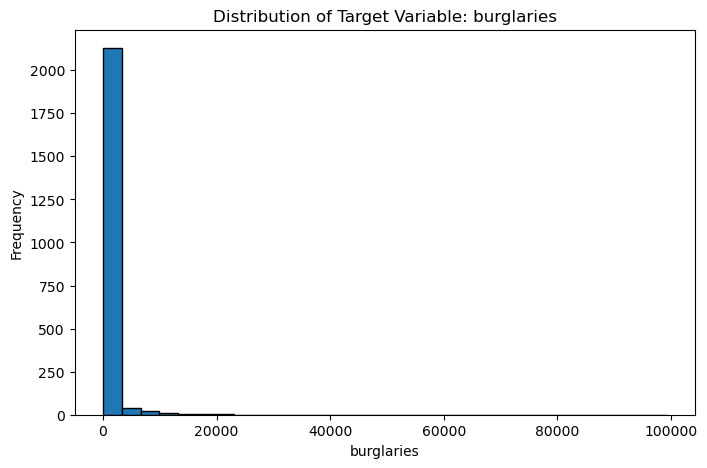

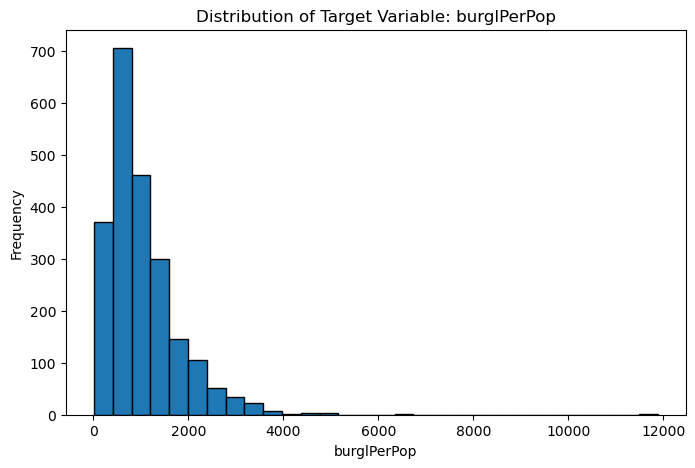

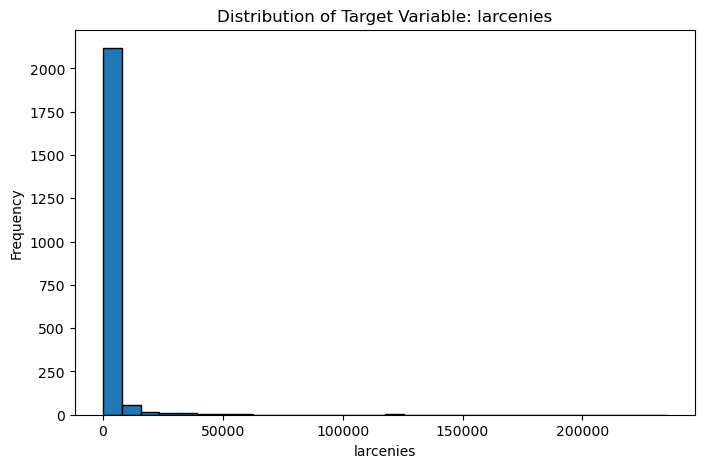

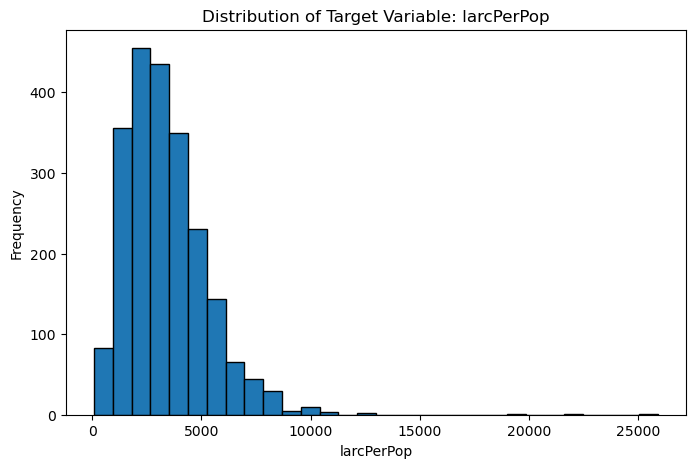

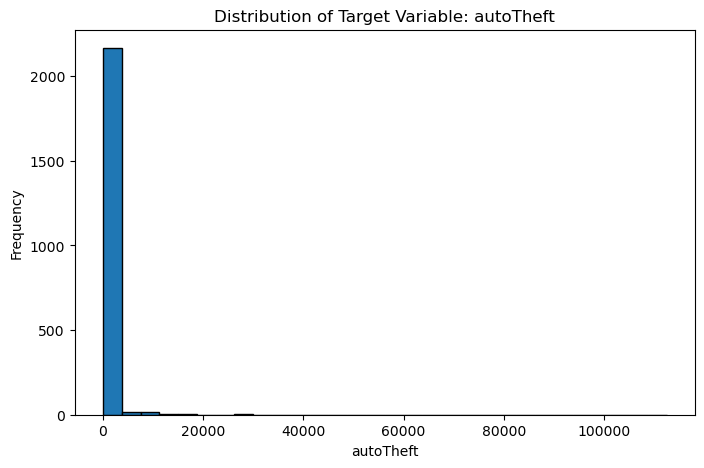

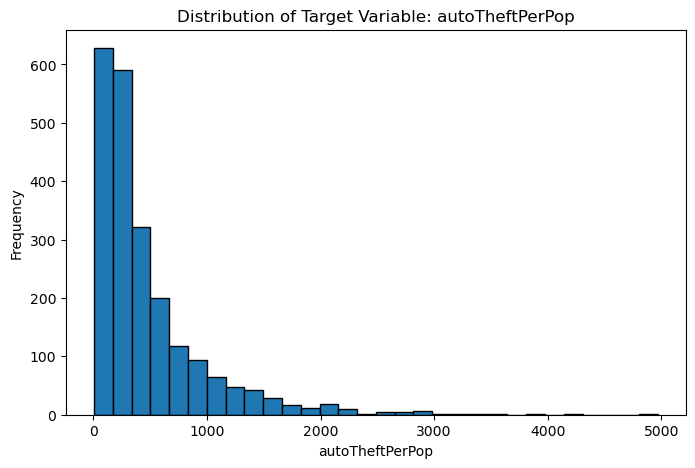

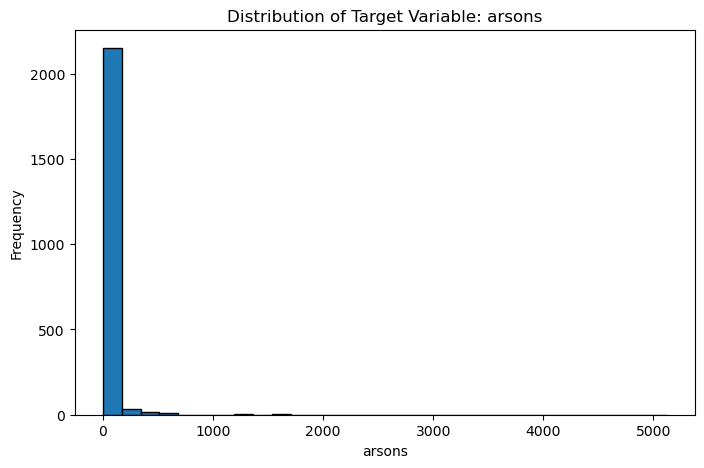

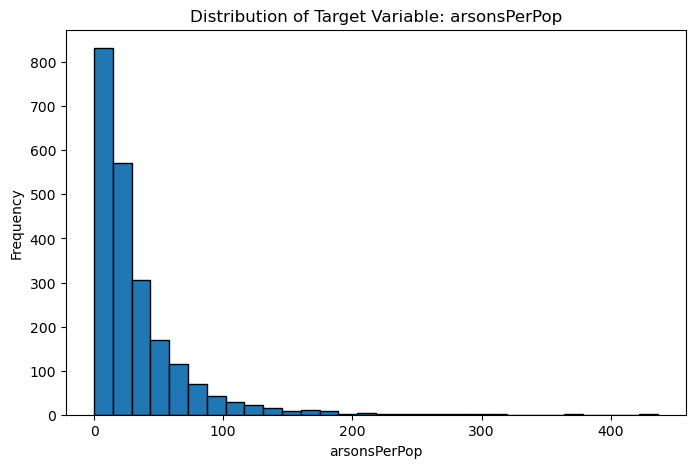

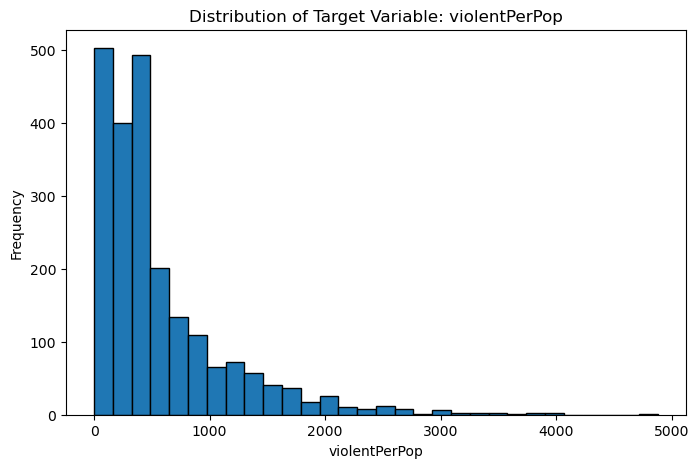

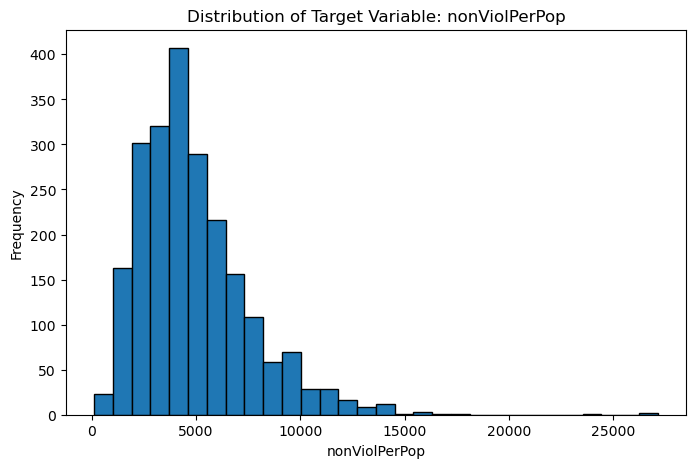

In [63]:
import matplotlib.pyplot as plt

# Plot the distribution of each target variable
for column in y.columns:
    plt.figure(figsize=(8, 5))
    plt.hist(y[column], bins=30, edgecolor='k')
    plt.title(f"Distribution of Target Variable: {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()
